# Extract Edge Image

## 1. Straight Track

In [19]:
import numpy as np
import random
import cv2

# Load and get initial edges
img = cv2.imread('straight_1.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# 1. Find each individual edge/dash
# RETR_EXTERNAL gets only the outer boundaries
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for i in range(0, 100):
    # 2. Create a blank canvas to draw the jittered result
    jittered_canvas = np.zeros_like(edges)

    # Define the maximum jitter range (in pixels)
    max_jitter = 2 
    
    # 3. Apply unique jitter to every individual contour
    for cnt in contours:
        # Generate a unique offset for THIS specific edge
        off_x = random.randint(-max_jitter, max_jitter)
        off_y = random.randint(-max_jitter, max_jitter)

        # Shift the coordinates of this contour
        shifted_cnt = cnt + [off_x, off_y]

        # Draw this specific shifted contour onto our canvas
        cv2.drawContours(jittered_canvas, [shifted_cnt], -1, 255, 1)

        # --- VISUALIZATION ---
        #cv2.imshow('Original Edges', edges)
        #cv2.imshow('Individually Jittered', jittered_canvas)
        #cv2.waitKey(0)
        #cv2.destroyAllWindows()
        cv2.imwrite("straight_edge_images/straight_edge_{0}.png".format(i), jittered_canvas) 

## 2. Curve Track

In [18]:
import numpy as np
import random
import cv2

# Load and get initial edges
img = cv2.imread('curve_left_1.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# 1. Find each individual edge/dash
# RETR_EXTERNAL gets only the outer boundaries
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for i in range(0, 100):
    # 2. Create a blank canvas to draw the jittered result
    jittered_canvas = np.zeros_like(edges)

    # Define the maximum jitter range (in pixels)
    max_jitter = 2 
    
    # 3. Apply unique jitter to every individual contour
    for cnt in contours:
        # Generate a unique offset for THIS specific edge
        off_x = random.randint(-max_jitter, max_jitter)
        off_y = random.randint(-max_jitter, max_jitter)

        # Shift the coordinates of this contour
        shifted_cnt = cnt + [off_x, off_y]

        # Draw this specific shifted contour onto our canvas
        cv2.drawContours(jittered_canvas, [shifted_cnt], -1, 255, 1)

        # --- VISUALIZATION ---
        #cv2.imshow('Original Edges', edges)
        #cv2.imshow('Individually Jittered', jittered_canvas)
        #cv2.waitKey(0)
        #cv2.destroyAllWindows()
        cv2.imwrite("curve_left_edge_images/curve_left_edge_{0}.png".format(i), jittered_canvas) 

# Create Random Straight Image

## 1. Single Straight Track

In [1]:
import os
api_key = os.environ.get("GOOGLE_API_KEY")

In [50]:
from google import genai
from google.genai import types
from PIL import Image
import glob
import random

edge_images = glob.glob("straight/straight_edge_images/*.png")
edge_image = random.choice(edge_images)
image = Image.open(edge_image)

client = genai.Client(api_key=api_key)

prompt = (
    "Please change the texture of '{}' image.".format(edge_image.split('/')[-1])
)

response = client.models.generate_content(
    model="gemini-3.1-flash-image-preview",
    contents=[prompt, image],
)

image_number = 28

for part in response.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = part.as_image()
        image.save("straight/straight_{0}.png".format(image_number))

I have updated the image with a textured background. The dark surface now features a realistic weathered asphalt texture with subtle gravel and crack details, and the boundary lines and center dashes have a slightly weathered white painted texture.


## 2. Mutiple Straight Track

In [260]:
from google import genai
from google.genai import types
from PIL import Image
import glob
import random

edge_images = glob.glob("straight/straight_edge_images/*.png")
#edge_image = random.choice(edge_images)
#image = Image.open(edge_image)

client = genai.Client(api_key=api_key)

for i in range(90, 10):
    edge_image = random.choice(edge_images)
    image = Image.open(edge_image)

    #prompt = (
    #    "Please fill out the inside of the edge to make it look like a track for domain randomization purposes to train the mobile robot. Please keep the angle of view, try to clearly distinguish between edges."
    #)
    prompt = (
        "Please change the texture of '{}' image.".format(edge_image.split('/')[-1])
    )
    
    response = client.models.generate_content(
        model="gemini-3.1-flash-image-preview",
        contents=[prompt, image],
    )

    for part in response.parts:
        if part.text is not None:
            print(part.text)
        elif part.inline_data is not None:
            image = part.as_image()
            image.save("straight_{0}.png".format(i))

I've updated the image to have a weathered asphalt texture, with worn white paint lines and small cracks, chips, and oil stains for a more realistic appearance.
I have transformed the texture of the original road design. It now features a central dashed line and side solid lines composed of glowing electrical circuits and plasma. This is set against a dark, metallic surface with an integrated, circuit-board-inspired pattern to create a high-tech, digital-highway feel.
I have updated the texture by giving the background a cracked, dry earth pattern and rendering the lane lines with a weathered, peeling paint effect.


# Create Curved track image that has same texture as straight image.

Combining images for horizontal comparison...
Displaying comparison...


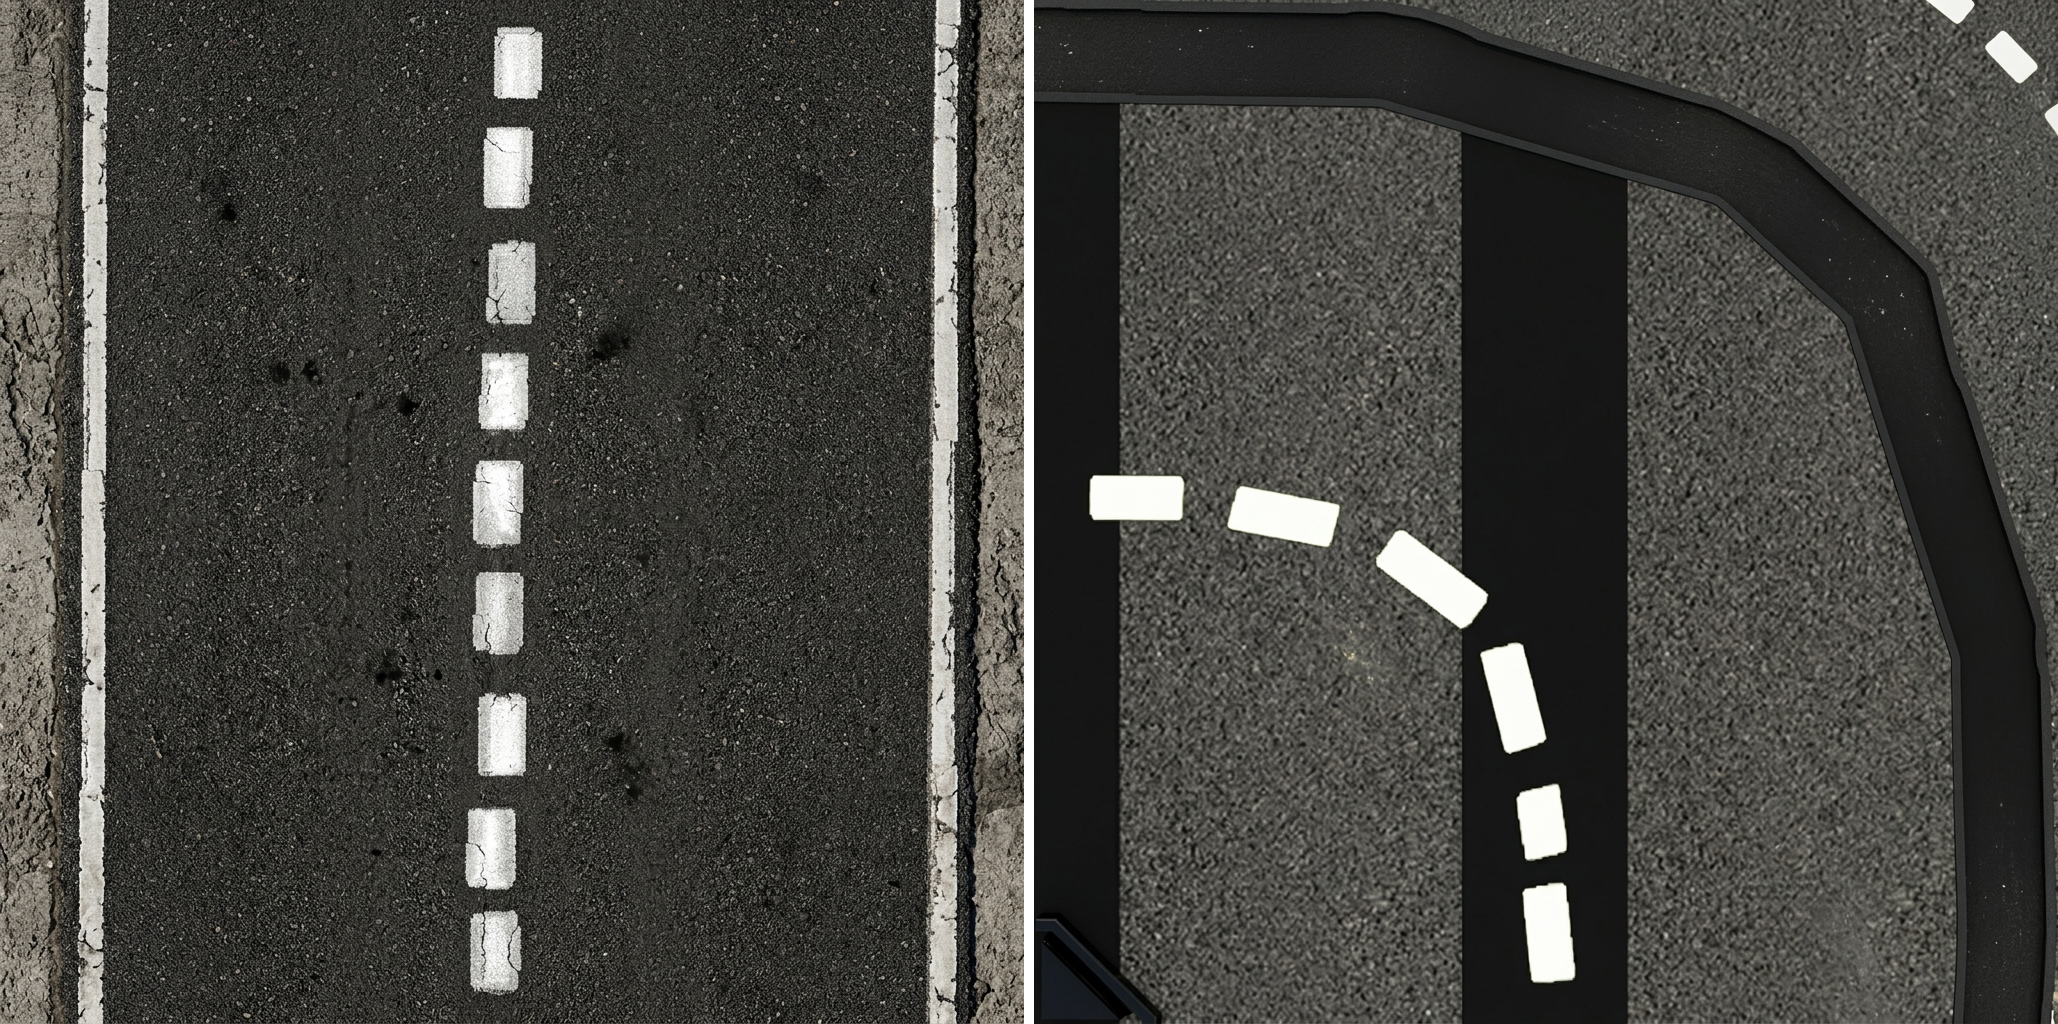

In [11]:
from PIL import Image
from IPython.display import display

def display_result(reference_image_number):
    print("Combining images for horizontal comparison...")
    
    # 1. Open both images again to ensure they are available
    ref_img = Image.open("straight/straight_{0}.png".format(reference_image_number))
    gen_img = Image.open("curve_left/curve_left_{0}.png".format(reference_image_number))
    
    # 2. Define heights and widths (handling potentially different sizes)
    width_ref, height_ref = ref_img.size
    width_gen, height_gen = gen_img.size
    
    # The new canvas width is the sum of both, and height is the max of both
    combined_width = width_ref + width_gen
    # Optionally, add a small gap
    gap = 10 
    combined_width += gap
    combined_height = max(height_ref, height_gen)
    
    # 3. Create a new empty (white) canvas
    combined_canvas = Image.new('RGB', (combined_width, combined_height), (255, 255, 255))
    
    # 4. Paste the images onto the canvas
    combined_canvas.paste(ref_img, (0, 0)) # First image at (0,0)
    combined_canvas.paste(gen_img, (width_ref + gap, 0)) # Second image offset by first width + gap
    
    # 5. Display the result
    print("Displaying comparison...")
    # combined_canvas.save('comparison.png') # Optional: Save the combined image
    #combined_canvas.show() # Standard Python OS pop-up
    # ... after pasting steps 1-4 ...
    display(combined_canvas)

display_result(4)

Combining images for horizontal comparison...
Displaying comparison...


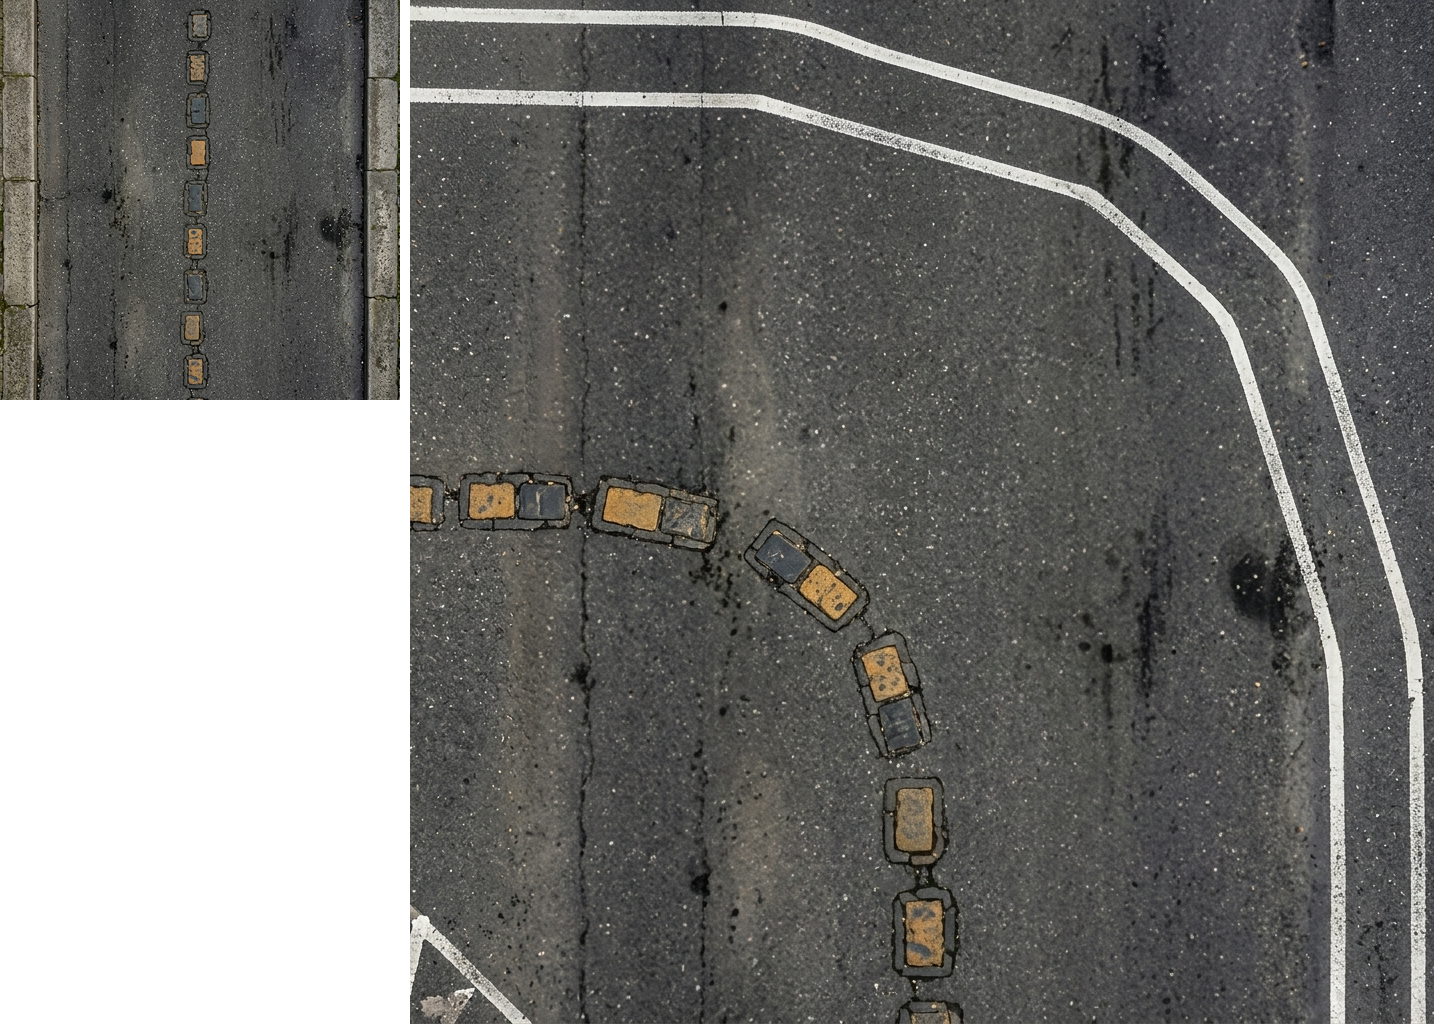

In [123]:
from google import genai
from google.genai import types
from PIL import Image
import random
import glob

edge_images = glob.glob("curve_left/curve_left_edge_images/*.png")
edge_image = random.choice(edge_images)
image = Image.open(edge_image)

reference_image_number = 84
image_reference = Image.open("straight/straight_{0}.png".format(reference_image_number))

client = genai.Client(api_key=api_key)

prompt = (
    "Please change the texture of '{0}' image.".format(edge_image.split('/')[-1])
)

response = client.models.generate_content(
    model="gemini-3.1-flash-image-preview",
    contents=[prompt, image, image_reference],
)

for part in response.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = part.as_image()
        image.save("curve_left/curve_left_{0}.png".format(reference_image_number))

display_result(reference_image_number)

# Resize Image

In [287]:
import os
import glob
from PIL import Image

# 1. Define the directory path
directory_path = "/curve_left"

# 2. Find all png and jpg files in the directory
# Using a list comprehension to catch both extensions if they exist
image_paths = glob.glob(os.path.join(directory_path, "*.png")) + glob.glob(os.path.join(directory_path, "*.jpg"))

if not image_paths:
    print(f"No images found in {directory_path}")
else:
    print(f"Found {len(image_paths)} images. Starting resize...")

    for path in image_paths:
        try:
            with Image.open(path) as img:
                # 3. Resize to 400x400
                # Using Resampling.LANCZOS for high-quality downsampling
                resized_img = img.resize((400, 400), Image.Resampling.LANCZOS)
                
                # 4. Save with the same name (overwrites the original)
                #print("path: ", path)
                resized_img.save(path)
                print(f"Processed: {os.path.basename(path)}")
        except Exception as e:
            print(f"Failed to process {path}: {e}")

print("Done!")

Found 100 images. Starting resize...
Processed: curve_left_19.png
Processed: curve_left_58.png
Processed: curve_left_65.png
Processed: curve_left_53.png
Processed: curve_left_28.png
Processed: curve_left_22.png
Processed: curve_left_7.png
Processed: curve_left_70.png
Processed: curve_left_18.png
Processed: curve_left_42.png
Processed: curve_left_68.png
Processed: curve_left_60.png
Processed: curve_left_3.png
Processed: curve_left_77.png
Processed: curve_left_52.png
Processed: curve_left_16.png
Processed: curve_left_38.png
Processed: curve_left_26.png
Processed: curve_left_12.png
Processed: curve_left_87.png
Processed: curve_left_43.png
Processed: curve_left_14.png
Processed: curve_left_50.png
Processed: curve_left_48.png
Processed: curve_left_8.png
Processed: curve_left_13.png
Processed: curve_left_61.png
Processed: curve_left_71.png
Processed: curve_left_69.png
Processed: curve_left_23.png
Processed: curve_left_74.png
Processed: curve_left_35.png
Processed: curve_left_20.png
Processed